In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout, Embedding, LSTM, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
training_data = pd.read_csv('/kaggle/input/twitter-entity-sentiment-analysis/twitter_training.csv')
testing_data = pd.read_csv('/kaggle/input/twitter-entity-sentiment-analysis/twitter_validation.csv')

In [4]:
training_data.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [5]:
testing_data.head()

,3364,Facebook,Irrelevant,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣"
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


In [6]:
training_data.describe()

,2401
count,74681.000000
mean,6432.640149
std,3740.423819
min,1.000000
25%,3195.000000
50%,6422.000000
75%,9601.000000
max,13200.000000


In [7]:
testing_data.describe()

,3364
count,999.000000
mean,6435.159159
std,3728.912226
min,6.000000
25%,3241.500000
50%,6560.000000
75%,9662.500000
max,13197.000000


In [8]:
print(f"training data shape: {training_data.shape}")
print(f"testing data shape: {testing_data.shape}")

training data shape: (74681, 4)
testing data shape: (999, 4)


In [9]:
training_data.columns = ['Id', 'Entity', 'Sentiment', 'Tweet']
testing_data.columns = ['Id', 'Entity', 'Sentiment', 'Tweet']

In [10]:
testing_data.head()

,Id,Entity,Sentiment,Tweet
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


In [11]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         74681 non-null  int64 
 1   Entity     74681 non-null  object
 2   Sentiment  74681 non-null  object
 3   Tweet      73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [12]:
training_data['Tweet'] = training_data['Tweet'].astype(str).fillna('')
testing_data['Tweet'] = testing_data['Tweet'].astype(str).fillna('')

In [13]:
training_data = training_data.drop(['Id', 'Entity'], axis=1)
testing_data = testing_data.iloc[:, 2:]

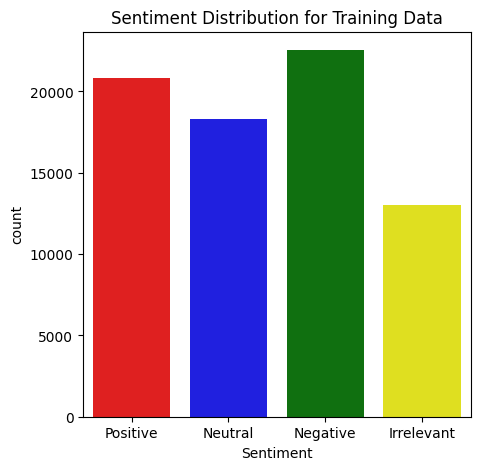

In [14]:
plt.figure(figsize=(5,5))
sns.countplot(x='Sentiment', data= training_data, palette=['Red','Blue','Green','Yellow'])
plt.title('Sentiment Distribution for Training Data')
plt.show()

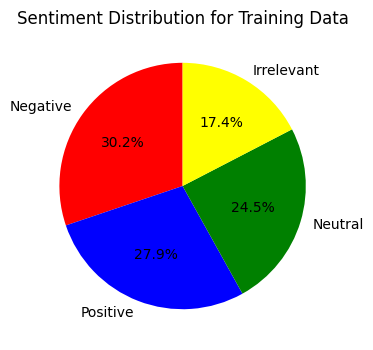

In [15]:
sentiment_counts = training_data['Sentiment'].value_counts()

plt.figure(figsize=(4, 4))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=['Red','Blue','Green','Yellow'])
plt.title('Sentiment Distribution for Training Data')
plt.show()

In [16]:
def clean_tweet(tweet):
  tweet = re.sub(r'http\S+|www\S+|https\S+', '', tweet, flags=re.MULTILINE)
  tweet = re.sub(r'\@\w+|\#', '', tweet)
  tweet = re.sub(r'[^A-Za-z\s]', '', tweet)
  tweet = tweet.lower()
  return tweet

In [17]:
training_data['cleaned_tweet'] = training_data['Tweet'].apply(clean_tweet)
testing_data['cleaned_tweet'] = testing_data['Tweet'].apply(clean_tweet)

In [18]:
label_encoder= LabelEncoder()

training_data['sentiment_encoded'] = label_encoder.fit_transform(training_data['Sentiment'])
testing_data['sentiment_encoded'] = label_encoder.transform(testing_data['Sentiment'])

print("Sentiment Classes and their Encoded Values:")
for index, sentiment in enumerate(label_encoder.classes_):
    print(f"{sentiment}: {index}")

Sentiment Classes and their Encoded Values:
Irrelevant: 0
Negative: 1
Neutral: 2
Positive: 3


In [19]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(training_data['cleaned_tweet']).toarray()
X_test_tfidf = tfidf.transform(testing_data['cleaned_tweet']).toarray()

In [20]:
y_train = training_data['sentiment_encoded']
y_test = testing_data['sentiment_encoded']

In [21]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_tfidf, y_train)
rf_predictions = rf_classifier.predict(X_test_tfidf)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f'RandomForestClassifier Accuracy: {rf_accuracy:.4f}')
print(classification_report(y_test, rf_predictions, target_names=label_encoder.classes_))

RandomForestClassifier Accuracy: 0.9660
              precision    recall  f1-score   support

  Irrelevant       0.99      0.96      0.97       171
    Negative       0.96      0.97      0.97       266
     Neutral       0.96      0.97      0.96       285
    Positive       0.97      0.96      0.96       277

    accuracy                           0.97       999
   macro avg       0.97      0.97      0.97       999
weighted avg       0.97      0.97      0.97       999



In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Function to evaluate different classifiers
def evaluate_classifier(classifier, X_train, y_train, X_test, y_test, name):
    classifier.fit(X_train, y_train)
    predictions = classifier.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f'{name} Accuracy: {accuracy:.4f}')
    print(classification_report(y_test, predictions, target_names=label_encoder.classes_))

# Instantiate classifiers
classifiers = [
    (LogisticRegression(max_iter=200,multi_class='multinomial', solver='lbfgs', random_state=42), "Logistic Regression"),
    (DecisionTreeClassifier(random_state=42), "Decision Tree Classifier"),
    (KNeighborsClassifier(n_neighbors=5), "K-Nearest Neighbors Classifier"),
]

# Evaluate classifiers using a loop
for classifier, name in classifiers:
    evaluate_classifier(classifier, X_train_tfidf, y_train, X_test_tfidf, y_test, name)


Logistic Regression Accuracy: 0.8018
              precision    recall  f1-score   support

  Irrelevant       0.77      0.68      0.72       171
    Negative       0.77      0.88      0.82       266
     Neutral       0.85      0.75      0.80       285
    Positive       0.80      0.86      0.83       277

    accuracy                           0.80       999
   macro avg       0.80      0.79      0.79       999
weighted avg       0.80      0.80      0.80       999

Decision Tree Classifier Accuracy: 0.9239
              precision    recall  f1-score   support

  Irrelevant       0.94      0.89      0.92       171
    Negative       0.92      0.95      0.94       266
     Neutral       0.93      0.92      0.92       285
    Positive       0.91      0.92      0.92       277

    accuracy                           0.92       999
   macro avg       0.93      0.92      0.92       999
weighted avg       0.92      0.92      0.92       999

K-Nearest Neighbors Classifier Accuracy: 0.9520
   

In [23]:
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(training_data['cleaned_tweet'])

In [24]:
train_sequences = tokenizer.texts_to_sequences(training_data['cleaned_tweet'])
test_sequences = tokenizer.texts_to_sequences(testing_data['cleaned_tweet'])

In [25]:
max_length = 100
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

In [26]:
print(f"Train padded shape: {train_padded.shape}")
print(f"Test padded shape: {test_padded.shape}")

Train padded shape: (74681, 100)
Test padded shape: (999, 100)


In [27]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

In [28]:
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
    Bidirectional(LSTM(64, return_sequences=False)),  # Bidirectional LSTM
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),  # Regularization
    Dropout(0.5),
    Dense(len(label_encoder.classes_), activation='softmax')
])

In [29]:
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [30]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lstm_history = lstm_model.fit(
    train_padded,
    y_train,
    epochs=20,  # Increased epochs for better training
    validation_data=(test_padded, y_test),
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.4430 - loss: 1.3346 - val_accuracy: 0.8168 - val_loss: 0.5756
Epoch 2/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.7495 - loss: 0.7441 - val_accuracy: 0.8849 - val_loss: 0.4025
Epoch 3/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8108 - loss: 0.5796 - val_accuracy: 0.9009 - val_loss: 0.3370
Epoch 4/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8383 - loss: 0.4906 - val_accuracy: 0.9309 - val_loss: 0.2639
Epoch 5/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8626 - loss: 0.4196 - val_accuracy: 0.9249 - val_loss: 0.2751
Epoch 6/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8772 - loss: 0.3711 - val_accuracy: 0.9439 - val_loss: 0.2229
Epoch 7/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8909 - loss: 0.3318 - val_accuracy: 0.9449 - val_loss: 0.2005
Epoch 8/20
1167/1167 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8989 -

In [38]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Plot training & validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot training & validation loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()


Plotting training history...


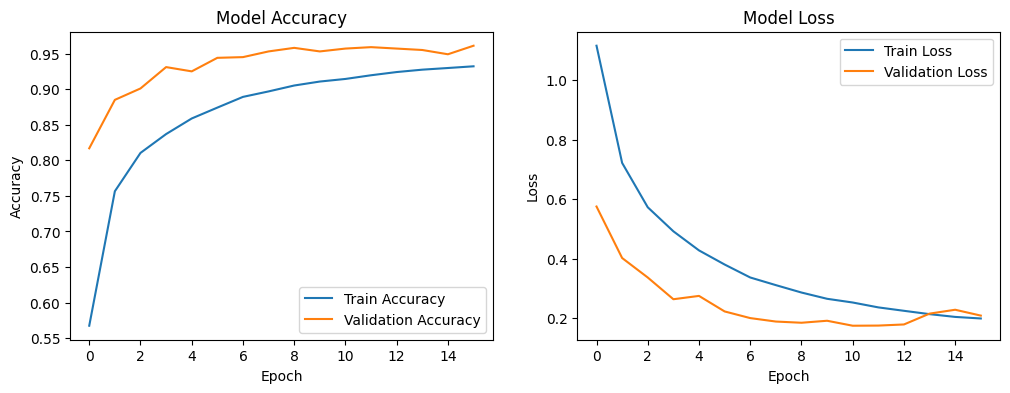

In [32]:
print("\nPlotting training history...")
plot_history(lstm_history)

In [39]:
print("\nEvaluating Bidirectional LSTM model on test data...")
lstm_loss, lstm_accuracy = lstm_model.evaluate(test_padded, y_test)
print(f'Bidirectional LSTM Model Test Accuracy: {lstm_accuracy:.4f}')


Evaluating Bidirectional LSTM model on test data...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9525 - loss: 0.1967
Bidirectional LSTM Model Test Accuracy: 0.9570


In [40]:
print("\nGenerating confusion matrix for BidirectionalLSTM model...")
y_pred_lstm = lstm_model.predict(test_padded)
y_pred_classes_lstm = np.argmax(y_pred_lstm, axis=1)


Generating confusion matrix for BidirectionalLSTM model...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [41]:
from sklearn.metrics import confusion_matrix
conf_matrix_lstm = confusion_matrix(y_test, y_pred_classes_lstm)

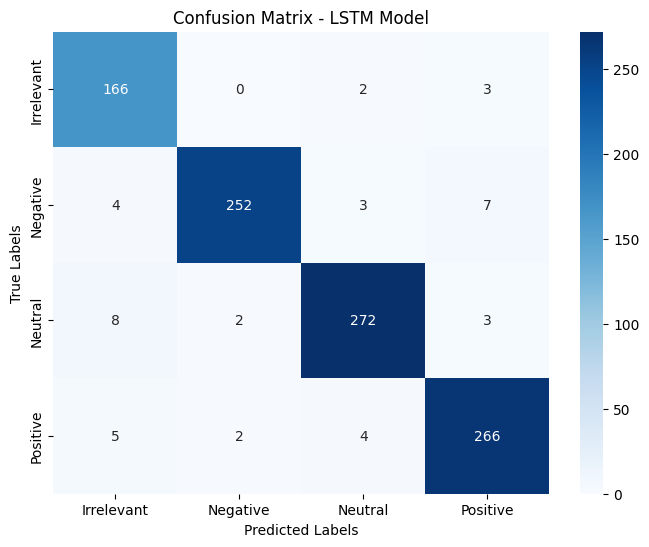

In [42]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - LSTM Model')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

In [43]:
print("Classification Report for LSTM Model:")
print(classification_report(y_test, y_pred_classes_lstm, target_names=label_encoder.classes_))

Classification Report for LSTM Model:
              precision    recall  f1-score   support

  Irrelevant       0.91      0.97      0.94       171
    Negative       0.98      0.95      0.97       266
     Neutral       0.97      0.95      0.96       285
    Positive       0.95      0.96      0.96       277

    accuracy                           0.96       999
   macro avg       0.95      0.96      0.96       999
weighted avg       0.96      0.96      0.96       999



In [48]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from transformers import BertTokenizer, TFBertForSequenceClassification
from tensorflow.keras.optimizers import Adam  # Use the correct TensorFlow Keras optimizer
import tensorflow as tf

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_tweets(tweets):
    return tokenizer(
        tweets,
        padding=True,
        truncation=True,
        max_length=100,
        return_tensors='tf'
    )

train_encodings = tokenize_tweets(training_data['cleaned_tweet'].tolist())
test_encodings = tokenize_tweets(testing_data['cleaned_tweet'].tolist())

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    training_data['sentiment_encoded'].values
)).shuffle(1000).batch(16)

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    testing_data['sentiment_encoded'].values
)).batch(16)

bert_model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(label_encoder.classes_))

bert_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), 
                   loss='sparse_categorical_crossentropy', 
                   metrics=['accuracy'])

# Train the BERT model
bert_history = bert_model.fit(train_dataset, epochs=3, validation_data=test_dataset)

# Plot training history for BERT
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Plot training & validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('BERT Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot training & validation loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('BERT Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(bert_history)

bert_loss, bert_accuracy = bert_model.evaluate(test_dataset)
print(f'BERT Model Test Accuracy: {bert_accuracy:.4f}')

y_pred_bert = bert_model.predict(test_dataset)
y_pred_classes_bert = np.argmax(y_pred_bert.logits, axis=1)

from sklearn.metrics import confusion_matrix

conf_matrix_bert = confusion_matrix(testing_data['sentiment_encoded'], y_pred_classes_bert)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_bert, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - BERT Model')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

from sklearn.metrics import classification_report
print("Classification Report for BERT Model:")
print(classification_report(testing_data['sentiment_encoded'], y_pred_classes_bert, target_names=label_encoder.classes_))
